# __Match OSMNX Links to TransCAD links to bring Atts: VELOCIDAD & CAPACIDAD__

### __DISCLAIMER:__ This match only works with OSMNX links __PRE-Visum__
### If match is attempted with Links from Visum it won't work because Visum changed their geometries too much from the original imported SHP (estan muy cuadradas y segmentadas)

In [31]:
import win32com.client as com
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
import numpy as np
from functools import lru_cache
from collections import defaultdict
from shapely.geometry import LineString
from shapely import wkt


## __Open Visum Net__

In [32]:
#Open network .ver file (from local disk not onedrive)
import win32com.client

#Visum = com.Dispatch("Visum.Visum.250") #Add .250 for Visum 25 version
Visum = com.Dispatch("Visum.Visum") #Visum 24 version
Visum.LoadVersion(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Modelación Urbana - Red Vial Guadalajara\Visum Projects\RedOSMNX_AMG_24 - Copy.ver')
C = win32com.client.constants

In [33]:
Net = Visum.Net

## __Read Links__

In [34]:
# Links
links = Visum.Net.Links
link_ids = links.GetMultiAttValues("No")
from_node = links.GetMultiAttValues("FromNodeNo")
to_node = links.GetMultiAttValues("ToNodeNo")
tsys_set = links.GetMultiAttValues("TSysSet")
lenght = links.GetMultiAttValues("Length")
num_lanes = links.GetMultiAttValues("NumLanes")
cap_prt = links.GetMultiAttValues("CapPrT")
v0_prt = links.GetMultiAttValues("V0PrT")
max_speed = links.GetMultiAttValues("MAXSPEED")
highway_type = links.GetMultiAttValues("HIGHWAY_NO")
geom_links = links.GetMultiAttValues("WKTPoly")

In [35]:
# Links DataFrame
visum_links = pd.DataFrame({
    "LinkNo": [l[1] for l in link_ids],
    "FromNode": [fn[1] for fn in from_node],
    "ToNode": [tn[1] for tn in to_node],
    "TSysSet": [t[1] for t in tsys_set],
    "NumLanes": [ln[1] for ln in num_lanes],
    "CapPrT": [c[1] for c in cap_prt],
    "V0PrT": [v[1] for v in v0_prt],
    "MAXSPEED": [ms[1] for ms in max_speed],
    "HIGHWAY": [h[1] for h in highway_type],
    "geometry": [gl[1] for gl in geom_links]
})

links = gpd.GeoDataFrame(
    visum_links, 
    geometry=visum_links["geometry"].apply(wkt.loads),
    crs="EPSG:4326")

In [36]:
links.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 593968 entries, 0 to 593967
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype   
---  ------    --------------   -----   
 0   LinkNo    593968 non-null  float64 
 1   FromNode  593968 non-null  float64 
 2   ToNode    593968 non-null  float64 
 3   TSysSet   593968 non-null  object  
 4   NumLanes  593968 non-null  float64 
 5   CapPrT    593968 non-null  float64 
 6   V0PrT     593968 non-null  float64 
 7   MAXSPEED  593968 non-null  object  
 8   HIGHWAY   593968 non-null  object  
 9   geometry  593968 non-null  geometry
dtypes: float64(6), geometry(1), object(3)
memory usage: 45.3+ MB


## __Read TransCAD Links with Velocidades__

In [37]:
transcad_links = gpd.read_file(r'C:\Users\AP03542515\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Modelación Urbana - Red Vial Guadalajara\Importacion TransCAD\drive-download-20260512T193400Z-3-001\AMG_RedVial_2023_con_limites_velocidad.shp')
transcad_links.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 139228 entries, 0 to 139227
Data columns (total 57 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   ID          139228 non-null  int64   
 1   LENGTH      139228 non-null  float64 
 2   DIR         139228 non-null  int32   
 3   IVTT        139228 non-null  float64 
 4   DRIVE_TIME  139228 non-null  float64 
 5   CONST_DRIV  139228 non-null  float64 
 6   WALK_TIME   139228 non-null  float64 
 7   CONST_WALK  139228 non-null  float64 
 8   MODE_WALK   139228 non-null  float64 
 9   CAPACIDAD   139228 non-null  int64   
 10  CARRILES    139228 non-null  int64   
 11  ESTACIONAM  138560 non-null  float64 
 12  MUNICIPIO   139031 non-null  float64 
 13  CALLE       130274 non-null  object  
 14  TIPO        139223 non-null  float64 
 15  TRANSPORTE  139228 non-null  int64   
 16  JERARQUIA   42 non-null      float64 
 17  NOMBRE      106028 non-null  object  
 18  ABPCE       1907

### __Las columnas que nos interesan son:__
- Limite_vel: límite de velocidad establecido de la vialidad
- CAPACIDAD: Capacidad en vehículos por hora de la vialidad
- Velocidad_: Promedio de velocidad de circulación de la vialidad calculado a partir de datos de uber

In [38]:
#Convertir a entero los valores de la columna 'Limite_vel' en el GeoDataFrame red_con_velocidades
transcad_links['Limite_vel'] = transcad_links['Limite_vel'].astype(int)
#Contar las filas para cada valor único de la columna 'Limite_vel' en el GeoDataFrame red_con_velocidades
transcad_links.groupby('Limite_vel').size()

Limite_vel
0        325
10        16
30    131153
40      4520
50      1059
60       569
80      1586
dtype: int64

Las que tienen velocidad 0 km/h son aquellos links por donde no se permite el paso de vehículos, como por ejemplo, calles peatonales. En transCAD era necesario agregarle una velocidad vehicular a estas calles por lo que al agregarles un límite de velocidad bajo el programa no les tomaba en cuenta para la asignación de tráfico.

### __Visualizar la red_con_velocidades con colores según los límites de velocidad__

<Axes: >

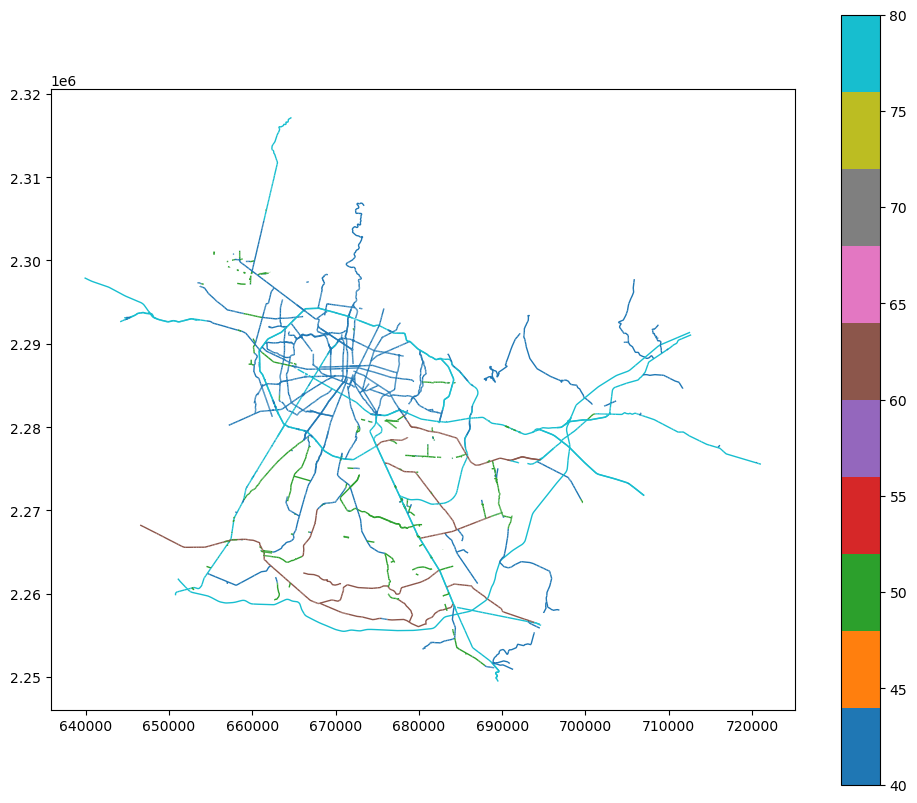

In [39]:
# Mapear tramos con velocidades mayores a 30 km/h
transcad_links[transcad_links["Limite_vel"] > 30].plot(
    column="Limite_vel",
    cmap="tab10",
    legend=True,
    figsize=(12, 10),
    linewidth=1
)

In [40]:
# stay only with those above 40 km/h
transcad_links=transcad_links[transcad_links["Limite_vel"] >= 40]

In [41]:
transcad_links.columns

Index(['ID', 'LENGTH', 'DIR', 'IVTT', 'DRIVE_TIME', 'CONST_DRIV', 'WALK_TIME',
       'CONST_WALK', 'MODE_WALK', 'CAPACIDAD', 'CARRILES', 'ESTACIONAM',
       'MUNICIPIO', 'CALLE', 'TIPO', 'TRANSPORTE', 'JERARQUIA', 'NOMBRE',
       'ABPCE', 'BAPCE', 'TOT_PVC_D', 'TOT_PVM_D', 'ABSPALTO', 'BASPALTO',
       'TOT_SPALTO', 'VOLTP_AB', 'VOLTP_BA', 'VOLTP_TOTA', 'CODIGO',
       'SECUENCIA', 'ANGULO', 'VEL_MOD', 'VEL_ALT', 'CALLEMIN', 'JERARQUIA_',
       'CARGA', 'IDLINK', 'RFJC', 'CAMELLON', 'CARRILES_A', 'CARRILES_B',
       'JERARQUÍA', 'IVTT_BRT', 'IVTT_EXP', 'VOLVP_AB', 'VOLVP_BA',
       'VOLTP2_TOT', 'CARRILES_M', 'FROM_LONGI', 'TO_LONGITU', 'FROM_LATIT',
       'TO_LATITUD', 'RELACIONTP', 'RELACIONT1', 'Velocidad_', 'Limite_vel',
       'geometry'],
      dtype='object')

### __Translate "Limite_vel" to Visum Links__

La siguiente celda de código contiene el algoritmo para pasar las columnas seleccionadas de la red vial de Imeplan a la red OSMNX. Lo hace mediante un buffer y vinculando todos los links que queden dentro del buffer, pero además comparando contra el ángulo que forman los links contra lo que estamos midiendo, para así no incluir links que sean perpendiculares o crucen

In [42]:
# Configuraciones iniciales
GDF_A = links             # Red destino (a la que le queremos pasar las columnas)
GDF_B = transcad_links          # Red fuente (de donde queremos extraer las columnas)

COLUMNAS = ["CAPACIDAD", "Velocidad_", "Limite_vel"]   # Columnas de GDF_B que queremos transferir a GDF_A

CRS_METRICO = "EPSG:32613"   # UTM zona 30N
BUFFER_M    = 25               # Radio del buffer en metros
MAX_ANGULO  = 35              # Diferencia máxima de ángulo permitida (grados)


# 1. Reproyectar a CRS métrico
a = GDF_A.to_crs(CRS_METRICO).copy().reset_index(drop=True)
b = GDF_B.to_crs(CRS_METRICO).copy().reset_index(drop=True)


# 2. Función: ángulo de un segmento (0–180°)
def angulo_linea(geom):
    """Devuelve el ángulo en grados del primer y último vértice (0–180°)."""
    try:
        coords = list(geom.coords) if geom.geom_type == "LineString" else \
                 list(geom.geoms[0].coords)
        p1, p2 = np.array(coords[0]), np.array(coords[-1])
        ang = np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0])) % 180
        return ang
    except Exception:
        return np.nan

a["_angulo"] = a.geometry.apply(angulo_linea)
b["_angulo"] = b.geometry.apply(angulo_linea)
b["_idx_b"]  = b.index          # guardamos el índice original de B


# 3. Buffer + spatial join (candidatos dentro del buffer)
a_buf = a.copy()
a_buf["geometry"] = a.geometry.buffer(BUFFER_M)

# sjoin: encuentra todos los links de B que caen dentro del buffer de A
candidatos = gpd.sjoin(b[["_idx_b", "_angulo", "geometry"] + COLUMNAS],
                       a_buf[["geometry", "_angulo"]].rename(columns={"_angulo": "_angulo_a"}),
                       how="inner", predicate="within")
# predicate="within", el link de B debe estar completamente dentro del buffer


# 4. Filtro por diferencia de ángulo < MAX_ANGULO grados
def diff_angulo(a1, a2):
    diff = abs(a1 - a2) % 180
    return min(diff, 180 - diff)    # simétrico: 170° y 10° son lo mismo

candidatos["_diff_ang"] = candidatos.apply(
    lambda r: diff_angulo(r["_angulo"], r["_angulo_a"]), axis=1
)
candidatos = candidatos[candidatos["_diff_ang"] < MAX_ANGULO]


# 5. Si hay varios candidatos, quedarse con el más cercano (menor distancia entre geometrías originales)
idx_a_col = "index_right"    # columna generada por sjoin con el índice de A

candidatos["_dist"] = candidatos.apply(
    lambda r: b.loc[r["_idx_b"], "geometry"].distance(
              a.loc[r[idx_a_col], "geometry"]), axis=1
)

mejor = (candidatos
         .sort_values("_dist")
         .groupby(idx_a_col, sort=False)
         .first()
         .reset_index()
         .rename(columns={idx_a_col: "_idx_a"}))


# 6. Transferir columnas a GDF_A
resultado = GDF_A.copy()
resultado = resultado.merge(
    mejor[["_idx_a"] + COLUMNAS].set_index("_idx_a"),
    left_index=True, right_index=True, how="left"
)

print(f"Links de A con match encontrado: {mejor['_idx_a'].nunique()} / {len(GDF_A)}")
print(f"Links sin match (NaN):           {resultado[COLUMNAS[0]].isna().sum()}")

resultado.head(5)

Links de A con match encontrado: 18608 / 593968
Links sin match (NaN):           575360


,LinkNo,FromNode,ToNode,TSysSet,NumLanes,CapPrT,V0PrT,MAXSPEED,HIGHWAY,geometry,CAPACIDAD,Velocidad_,Limite_vel
0,1.0,1.0,103492.0,"B,C",1.0,0.0,0.0,80,['motorway'],"LINESTRING (-103.2463 20.6161, -103.2473 20.61...",2000.0,34.0,80.0
1,1.0,103492.0,1.0,,1.0,0.0,0.0,,,"LINESTRING (-103.2905 20.6279, -103.2894 20.62...",2000.0,34.0,80.0
2,2.0,1.0,15708.0,"B,C",1.0,0.0,0.0,,['motorway_link'],"LINESTRING (-103.2463 20.6161, -103.2465 20.61...",NaN,NaN,NaN
3,2.0,15708.0,1.0,,1.0,0.0,0.0,,,"LINESTRING (-103.2477 20.6163, -103.2475 20.61...",NaN,NaN,NaN
4,3.0,2.0,3.0,"B,C",1.0,0.0,0.0,,['motorway'],"LINESTRING (-103.1364 20.6056, -103.1343 20.60...",NaN,NaN,NaN


## __Por que hay muchos menos matches?__
Sí, exactamente.

Lo más probable es que los links de Visum no sean geométricamente iguales al shapefile original. Al importar a Visum se pueden:

fragmentar tramos en más segmentos
agregar nodos intermedios
recortar o ajustar la geometría
cambiar la dirección / orden de los vértices
usar otra precisión espacial
Tu algoritmo actual:

usa within sobre un buffer de 25 m
filtra por ángulo
toma el candidato más cercano
Eso funciona bien si las geometrías son muy parecidas. Pero si la red de Visum está más segmentada o desplazada, muchos links B ya no quedan “completamente dentro” del buffer de A, y por eso baja tanto el match.

Entonces sí:

los links de Visum cambiaron más geometrías,
y por eso no caen tan cerca del original.

<Axes: >

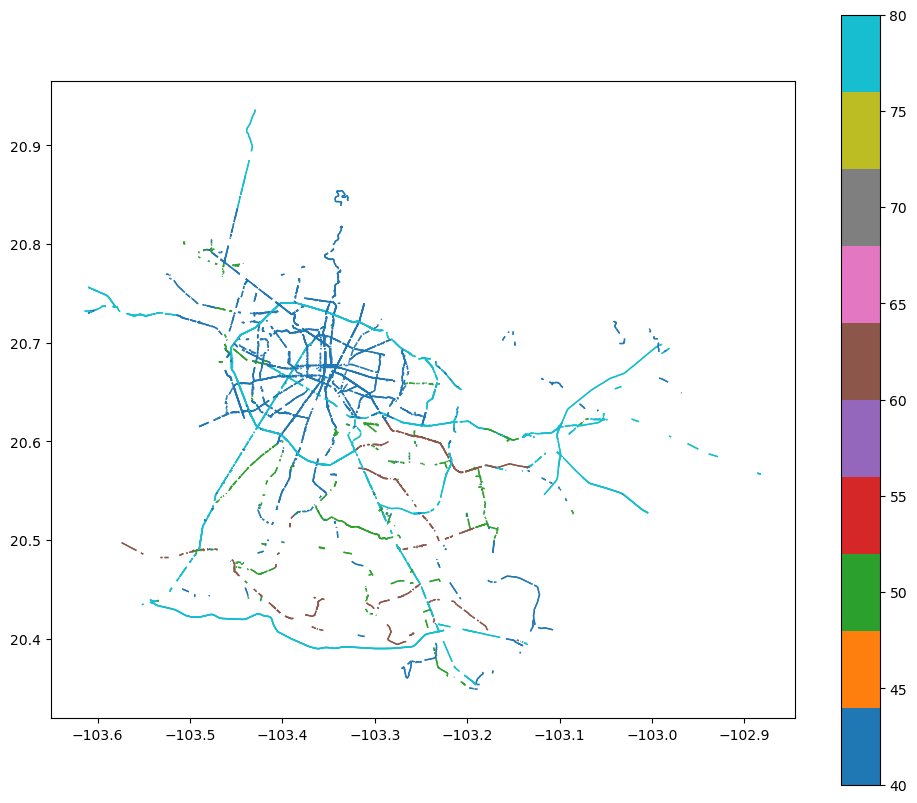

In [43]:
# Visualizar para valores de Limite_vel mayores 30 para mejor lectura
resultado[resultado["Limite_vel"] > 30].plot(
    column="Limite_vel",
    cmap="tab10",
    legend=True,
    figsize=(12, 10),
    linewidth=1
)